In [1]:
# 1.Given a CSV file containing Zomato restaurant ratings, use pandas to detect outliers in the 'user_rating' column using the IQR method and print the indices of the detected outliers.
import pandas as pd

# Read Zomato CSV
df = pd.read_csv("zomato_ratings.csv")

# Calculate Q1, Q3 and IQR
Q1 = df["user_rating"].quantile(0.25)
Q3 = df["user_rating"].quantile(0.75)

IQR = Q3 - Q1

# Calculate limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Find outliers
outliers = df[
    (df["user_rating"] < lower_limit) |
    (df["user_rating"] > upper_limit)
]

print("Outlier indices:")
print(outliers.index)

print("\nOutlier values:")
print(outliers["user_rating"])

Outlier indices:
RangeIndex(start=8, stop=9, step=1)

Outlier values:
8    1.2
Name: user_rating, dtype: float64


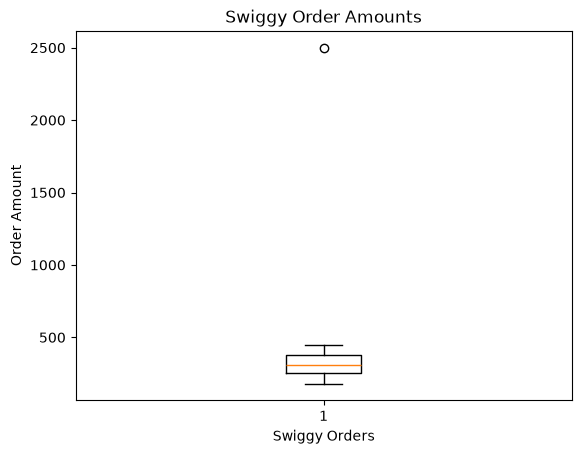

In [2]:
# 2.Create a boxplot for the 'order_amount' column from a Swiggy orders dataset using matplotlib, and visually identify any outliers present.<br><br><em><strong>Hint:</strong> Use plt.boxplot() and label your axes for clarity.</em>
import pandas as pd
import matplotlib.pyplot as plt

# Read Swiggy orders CSV
df = pd.read_csv("swiggy_orders.csv")

# Create boxplot
plt.boxplot(df["order_amount"])

plt.title("Swiggy Order Amounts")
plt.ylabel("Order Amount")
plt.xlabel("Swiggy Orders")

plt.show()

In [3]:
# 3.Apply winsorization to the 'transaction_amount' column in a Paytm transactions DataFrame to cap all values above the 95th percentile and below the 5th percentile, then display the updated column statistics.
import pandas as pd

df = pd.DataFrame({
    "transaction_amount": [
        100, 150, 200, 250, 300,
        350, 400, 450, 500, 10000
    ]
})

print("Before winsorization:")
print(df["transaction_amount"].describe())

# Find 5th and 95th percentiles
lower = df["transaction_amount"].quantile(0.05)
upper = df["transaction_amount"].quantile(0.95)

# Apply winsorization
df["transaction_amount"] = df["transaction_amount"].clip(
    lower=lower,
    upper=upper
)

print("\nAfter winsorization:")
print(df["transaction_amount"].describe())

Before winsorization:
count       10.000000
mean      1270.000000
std       3070.124862
min        100.000000
25%        212.500000
50%        325.000000
75%        437.500000
max      10000.000000
Name: transaction_amount, dtype: float64

After winsorization:
count      10.000000
mean      844.750000
std      1719.321753
min       122.500000
25%       212.500000
50%       325.000000
75%       437.500000
max      5725.000000
Name: transaction_amount, dtype: float64


In [5]:
# 4.You have a DataFrame of Flipkart product prices stored as strings with currency symbols (e.g., '₹1,299'). Convert this column to numeric type using pandas, ensuring all non-numeric characters are removed.<br><br><em><strong>Hint:</strong> Use str.replace() and astype().</em>
import pandas as pd

df = pd.DataFrame({
    "price": ["₹1,299", "₹2,499", "₹999", "₹10,999", "₹5,500"]
})

print("Before:")
print(df)


df["price"] = (
    df["price"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

print("\nAfter:")
print(df)

print("\nData type:")
print(df["price"].dtype)

Before:
     price
0   ₹1,299
1   ₹2,499
2     ₹999
3  ₹10,999
4   ₹5,500

After:
     price
0   1299.0
1   2499.0
2    999.0
3  10999.0
4   5500.0

Data type:
float64


In [7]:
# 5.Fix the following code snippet where the 'is_premium' column in a Spotify user DataFrame is a mix of boolean, string, and integer types. Convert the entire column to boolean type, treating 'True', 1, and 'yes' as True, and everything else as False.
import pandas as pd

df = pd.DataFrame({
    "username": ["Amit", "Rahul", "Priya", "Neha", "Raj", "Kiran"],
    "is_premium": [True, "True", 1, "yes", "No", 0]
})

print("Before:")
print(df)

df["is_premium"] = df["is_premium"].apply(
    lambda x: True
    if str(x).strip().lower() in ["true", "1", "yes"]
    else False
)

print("\nAfter conversion:")
print(df)

print("\nData type:")
print(df["is_premium"].dtype)

Before:
  username is_premium
0     Amit       True
1    Rahul       True
2    Priya          1
3     Neha        yes
4      Raj         No
5    Kiran          0

After conversion:
  username  is_premium
0     Amit        True
1    Rahul        True
2    Priya        True
3     Neha        True
4      Raj       False
5    Kiran       False

Data type:
bool
